In [12]:
import pandas as pd
import sys 
import os 

project_root = os.path.abspath(os.path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)


from src.preprocessing import preprocess_data

file_path = r"../data/RA_Dataset.xlsx"
output_path = r"../data/RA_dataset_cleaned.csv"

In [13]:
df_cleaned=preprocess_data(file_path)
df_cleaned.to_csv(output_path, index=False)

df_cleaned.head(10)

#df_cleaned[['previous_flare', 'flare_event']].head(20)

Dropping columns with > 50.0% missing values: smoking,tjc_28,sjc_28,vas


,patient_id,gender,year_of_diagnosis,rf_status,anti_ccp_status,comorbidities,visit_date,visit_type,crp,crp_upper_limit,...,comorb_renal_urological,comorb_gastrointestinal_hepatic,comorb_malignancy,comorb_musculoskeletal,comorb_neurologic_psychiatric,comorb_autoimmune_other,comorbidity_count,csdmard_use,b_ts_dmard_use,steroid_use
0,RA001,1,1997,0,0,"depression,hypothyroidism",2017-12-18,Baseline,0.40,0.5,...,0,0,0,0,1,0,2,1,1,0
1,RA001,1,1997,0,0,"depression,hypothyroidism",2018-03-20,Follow-up,NaN,NaN,...,0,0,0,0,1,0,2,1,1,0
2,RA001,1,1997,0,0,"depression,hypothyroidism",2018-09-25,Follow-up,0.40,0.5,...,0,0,0,0,1,0,2,1,1,0
4,RA002,1,1999,0,0,,2023-10-27,Baseline,0.02,0.5,...,0,0,0,0,0,0,0,1,1,0
5,RA002,1,1999,0,0,,2024-01-30,Follow-up,0.07,0.5,...,0,0,0,0,0,0,0,1,1,0
6,RA002,1,1999,0,0,,2024-04-23,Follow-up,1.90,5.0,...,0,0,0,0,0,0,0,1,1,0
7,RA002,1,1999,0,0,,2024-09-17,Follow-up,0.10,0.5,...,0,0,0,0,0,0,0,1,1,0
9,RA003,0,2005,1,1,transient ischemic attack,2023-09-01,Baseline,0.46,0.5,...,0,0,0,0,0,0,1,1,1,0
11,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-05-16,Baseline,NaN,NaN,...,0,0,0,0,0,0,1,1,1,1
12,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-09-20,Follow-up,6.60,5.0,...,0,0,0,0,0,0,1,1,1,1


In [10]:
import pandas as pd
import re
from collections import Counter

def clean_comorbidity_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower().strip()
    
    # normalize separators
    text = text.replace(";", ",")
    text = text.replace("/", ",")
    text = re.sub(r"\s+", " ", text)
    
    # remove extra spaces around commas
    text = re.sub(r"\s*,\s*", ",", text)
    
    return text

def split_comorbidities(text):
    if not text:
        return []
    return [x.strip() for x in text.split(",") if x.strip()]

# clean column
df_cleaned["comorbidities_clean"] = df_cleaned["comorbidities"].apply(clean_comorbidity_text)

# flatten all comorbidities into one list
all_comorbidities = []
for txt in df_cleaned["comorbidities_clean"]:
    all_comorbidities.extend(split_comorbidities(txt))

# frequency table
freq = pd.DataFrame(Counter(all_comorbidities).items(), columns=["comorbidity", "count"])
freq = freq.sort_values("count", ascending=False).reset_index(drop=True)

print(freq)

                  comorbidity  count
0                dyslipidemia     74
1                osteoporosis     49
2                hypertension     37
3              hypothyroidism     33
4                        gerd     30
5                          oa     26
6                          af     21
7                         cad     21
8        resolved hepatitis b     17
9                        mgus     13
10               tuberculosis     13
11         sjogren's syndrome     13
12          diabetes mellitus     11
13                        btm     10
14                       copd      9
15           carotid stenosis      8
16         antidepressant use      8
17                 depression      8
18                hepatitis b      7
19                       gout      7
20                   hasimoto      5
21            solitary kidney      5
22                         hf      4
23               pericarditis      4
24                thalassemia      4
25           cushing syndrome      4
2

In [49]:
df_cleaned.nlargest(10, 'crp_normalized')[['patient_id','visit_date','crp','crp_upper_limit','crp_normalized']]

,patient_id,visit_date,crp,crp_upper_limit,crp_normalized
208,RA050,2018-08-13,16.00,0.5,32.00
165,RA042,2016-12-19,14.20,0.5,28.40
27,RA007,2020-02-24,62.50,5.0,12.50
130,RA032,2016-10-17,5.15,0.5,10.30
236,RA056,2018-06-15,57.90,6.0,9.65
162,RA042,2016-04-05,4.50,0.5,9.00
161,RA042,2016-01-11,37.50,5.0,7.50
158,RA041,2023-05-26,3.71,0.5,7.42
126,RA031,2016-09-27,3.70,0.5,7.40
160,RA042,2015-12-02,3.04,0.5,6.08


In [4]:
df_cleaned['das28_score'].isna().mean()

np.float64(0.41228070175438597)

In [9]:
df_cleaned.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 228 entries, 0 to 296
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   patient_id                       228 non-null    str           
 1   gender                           228 non-null    Int64         
 2   year_of_diagnosis                226 non-null    Int64         
 3   rf_status                        225 non-null    Int64         
 4   anti_ccp_status                  225 non-null    Int64         
 5   comorbidities                    228 non-null    str           
 6   visit_date                       228 non-null    datetime64[us]
 7   visit_type                       228 non-null    str           
 8   crp                              162 non-null    float64       
 9   crp_upper_limit                  162 non-null    float64       
 10  esr                              192 non-null    float64       
 11  das28_sco

In [20]:
missing_report = df_cleaned[['das28_score', 'crp', 'esr', 'tjc_28']].isnull().mean() * 100
print(missing_report)

das28_score    41.610738
crp            28.523490
esr            19.127517
tjc_28         52.348993
dtype: float64


In [32]:
# How many visits have flare_event recorded
print("Total visits with flare_event:", df_cleaned['target_flare_next'].notna().sum())

# Class distribution
print(df_cleaned['target_flare_next'].value_counts(normalize=True) * 100)

# Count usable rows with all predictors
predictors = ['das28_score','crp','esr','csdmard_name','steroid_dose','b_ts_dmard_name']
usable_rows = df_cleaned.dropna(subset=['target_flare_next'] + predictors).shape[0]
print("Usable rows for ML:", usable_rows)

Total visits with flare_event: 228
target_flare_next
No     60.526316
Yes    39.473684
Name: proportion, dtype: float64
Usable rows for ML: 93


patient_id                 0
gender                     0
year_of_diagnosis          3
rf_status                  5
anti_ccp_status            5
comorbidities             81
visit_date                 0
visit_type                 0
tjc_28                   156
sjc_28                   156
crp                       85
crp_upper_limit           86
esr                       57
vas                      161
das28_score              124
csdmard_name               0
mtx_use                    0
mtx_dose                   0
b_ts_dmard_name            0
steroid_dose               0
treatment_decision        71
switch_reason              0
flare_event                0
source                     0
birth_year                 0
days_since_last_visit      0
disease_duration           3
age_at_visit               0
das28_change               0
target_flare_next         70
dtype: int64


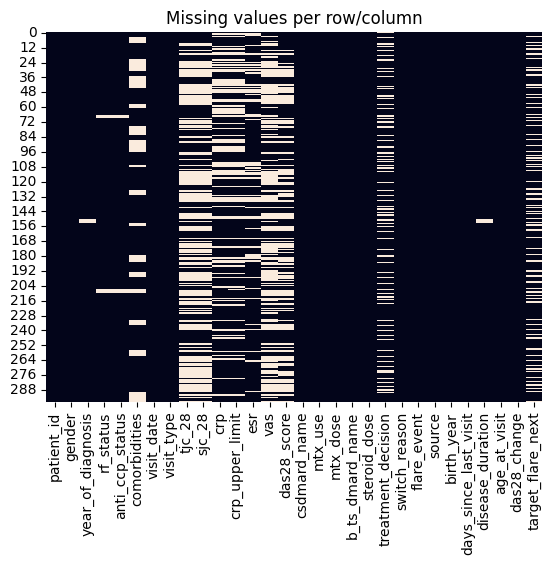

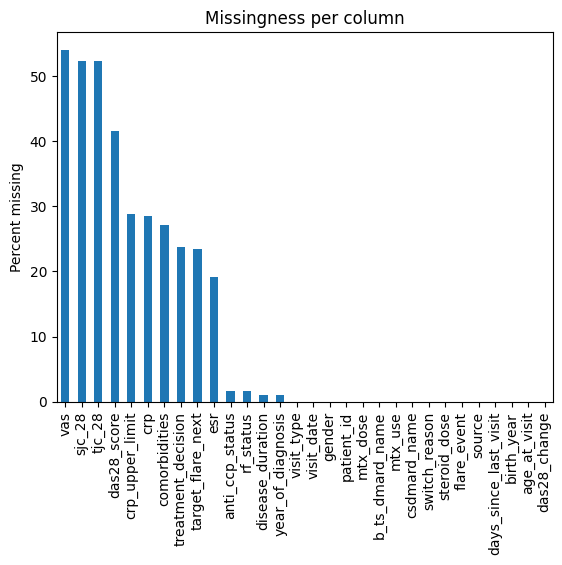

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Quick missingness table
print(df_cleaned.isnull().sum())

# Visual missingness heatmap
sns.heatmap(df_cleaned.isnull(), cbar=False)
plt.title("Missing values per row/column")
plt.show()

# Percentage missing per column
missing_percent = df_cleaned.isnull().mean() * 100
missing_percent.sort_values(ascending=False).plot(kind='bar')
plt.ylabel("Percent missing")
plt.title("Missingness per column")
plt.show()

In [ ]:
df_cleaned['esr_missing'] = df_cleaned['esr'].isna().astype(int)
pd.crosstab(df_cleaned['esr_missing'], df_cleaned['target_flare_next'])

target_flare_next,0,1
esr_missing,,
0,112,80
1,26,10


Συνολικές Επισκέψεις:
flare_event
No     169
Yes    129
Name: count, dtype: int64

Ποσοστά (%):
flare_event
No     56.711409
Yes    43.288591
Name: proportion, dtype: float64


C:\Users\konna\AppData\Local\Temp\ipykernel_16180\836409855.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flare_counts.index, y=flare_counts.values, palette='viridis')


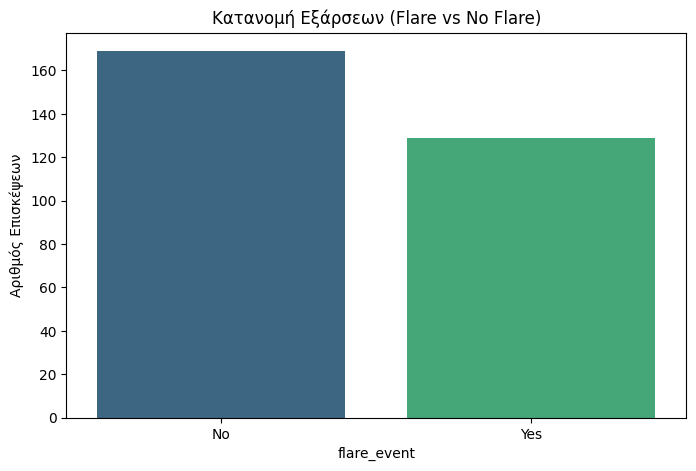

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Υπολογισμός συχνότητας
flare_counts = df_cleaned['flare_event'].value_counts()
flare_perc = df_cleaned['flare_event'].value_counts(normalize=True) * 100

print("Συνολικές Επισκέψεις:")
print(flare_counts)
print("\nΠοσοστά (%):")
print(flare_perc)

# Οπτικοποίηση
plt.figure(figsize=(8,5))
sns.barplot(x=flare_counts.index, y=flare_counts.values, palette='viridis')
plt.title('Κατανομή Εξάρσεων (Flare vs No Flare)')
plt.ylabel('Αριθμός Επισκέψεων')
plt.show()

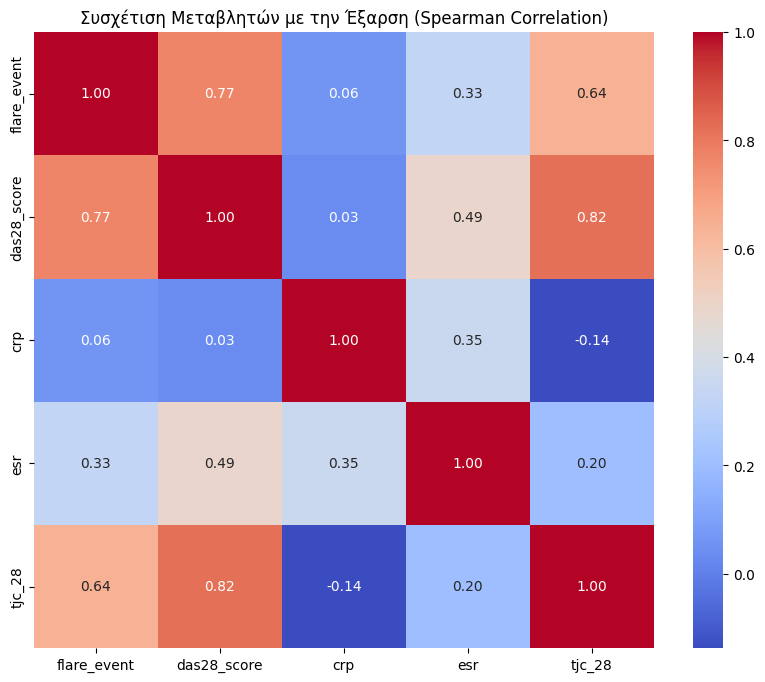

In [12]:
# Υπολογισμός συσχέτισης (χρησιμοποιούμε Spearman γιατί οι ιατρικές τιμές συχνά δεν είναι κανονικά κατανεμημένες)
corr_df = df_cleaned[['flare_event', 'das28_score', 'crp', 'esr', 'tjc_28']].copy()
corr_df['flare_event'] = corr_df['flare_event'].map({'No': 0, 'Yes': 1})
correlations = corr_df.corr(method='spearman', numeric_only=True)

# Οπτικοποίηση με Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Συσχέτιση Μεταβλητών με την Έξαρση (Spearman Correlation)')
plt.show()

In [9]:
df_cleaned.describe()

,year_of_diagnosis,visit_date,tjc_28,sjc_28,crp,crp_upper_limit,esr,vas,das28_score,mtx_dose,steroid_dose,birth_year,days_since_last_visit,disease_duration,age_at_visit
count,233.0,236,116.000000,116.000000,160.000000,159.000000,184.000000,109.000000,141.000000,235.000000,236.000000,236.0,236.000000,233.0,236.0
mean,2007.0,2021-03-14 20:38:38.644067,3.646552,1.422414,3.688594,3.021384,26.494565,40.412844,3.618085,7.476596,4.572034,1958.372881,177.707627,13.648069,62.300847
min,1981.0,2015-03-03 00:00:00,0.000000,0.000000,0.010000,0.050000,2.000000,0.000000,1.050000,0.000000,0.000000,1937.0,0.000000,0.0,37.0
25%,1999.0,2019-02-09 12:00:00,1.000000,0.000000,0.300000,0.500000,13.000000,20.000000,2.800000,0.000000,0.000000,1948.0,26.750000,3.0,54.75
50%,2011.0,2021-03-27 00:00:00,3.000000,1.000000,1.000000,5.000000,22.000000,40.000000,3.450000,0.000000,0.000000,1956.5,104.000000,11.0,63.0
75%,2015.0,2023-10-21 18:00:00,5.250000,2.000000,3.577500,5.000000,36.000000,50.000000,4.440000,15.000000,5.000000,1967.0,259.250000,21.0,72.0
max,2025.0,2026-02-24 00:00:00,25.000000,8.000000,62.500000,8.000000,105.000000,90.000000,6.800000,25.000000,500.000000,1983.0,1413.000000,44.0,84.0
std,11.749541,NaN,3.804469,1.804106,7.443581,2.490821,18.993815,21.485659,1.226886,8.634338,32.568440,11.189126,209.196180,11.969995,11.709541


In [14]:
# ===== Dataset Diagnostics =====

print("===== DATASET OVERVIEW =====")

# Total visits and patients
total_visits = len(df_cleaned)
total_patients = df_cleaned['patient_id'].nunique()

print(f"Total visits: {total_visits}")
print(f"Total patients: {total_patients}")

# Visits per patient
visits_per_patient = df_cleaned.groupby('patient_id').size()

print("\n--- Visits per patient ---")
print(visits_per_patient.describe())

# Possible visit pairs
pairs_per_patient = visits_per_patient - 1
pairs_per_patient = pairs_per_patient[pairs_per_patient > 0]

total_possible_pairs = pairs_per_patient.sum()

print("\n--- Visit pairing ---")
print(f"Total possible visit pairs: {total_possible_pairs}")

# Create shifted DAS28
df_tmp = df_cleaned.sort_values(['patient_id', 'visit_date']).copy()
df_tmp['das28_next'] = df_tmp.groupby('patient_id')['das28_score'].shift(-1)

pairs_with_next_visit = df_tmp['das28_next'].notna().sum()

print(f"Rows with next visit available: {pairs_with_next_visit}")

# Missing DAS28
missing_das28 = df_cleaned['das28_score'].isna().sum()
missing_percent = df_cleaned['das28_score'].isna().mean() * 100

print("\n--- DAS28 completeness ---")
print(f"Missing DAS28 values: {missing_das28} ({missing_percent:.1f}%)")

# Pairs with both DAS28 values
valid_pairs = df_tmp.dropna(subset=['das28_score', 'das28_next'])

print("\n--- Usable longitudinal pairs ---")
print(f"Pairs with DAS28 now and next: {len(valid_pairs)}")

print("\n===== SUMMARY =====")
print(f"Visits: {total_visits}")
print(f"Patients: {total_patients}")
print(f"Possible visit pairs: {total_possible_pairs}")
print(f"Pairs with next visit: {pairs_with_next_visit}")
print(f"Pairs with complete DAS28: {len(valid_pairs)}")

===== DATASET OVERVIEW =====
Total visits: 298
Total patients: 70

--- Visits per patient ---
count    70.000000
mean      4.257143
std       2.204644
min       2.000000
25%       3.000000
50%       4.000000
75%       5.000000
max      14.000000
dtype: float64

--- Visit pairing ---
Total possible visit pairs: 228
Rows with next visit available: 139

--- DAS28 completeness ---
Missing DAS28 values: 124 (41.6%)

--- Usable longitudinal pairs ---
Pairs with DAS28 now and next: 98

===== SUMMARY =====
Visits: 298
Patients: 70
Possible visit pairs: 228
Pairs with next visit: 139
Pairs with complete DAS28: 98


In [62]:
df_cleaned.isna().sum()

patient_id                 0
gender                     0
year_of_diagnosis          2
rf_status                  3
anti_ccp_status            3
comorbidities             63
visit_date                 0
visit_type                 0
tjc_28                   120
sjc_28                   120
crp                       66
crp_upper_limit           67
esr                       36
vas                      122
das28_score               94
csdmard_name               0
mtx_use                    0
mtx_dose                   0
b_ts_dmard_name            0
steroid_dose               0
treatment_decision        70
switch_reason              0
flare_event                0
source                     0
birth_year                 0
days_since_last_visit      0
disease_duration           2
age_at_visit               0
das28_change               0
target_flare_next          0
crp_normalized            67
inflammation_flag          0
esr_normalized            36
inflammation_score        75
dtype: int64

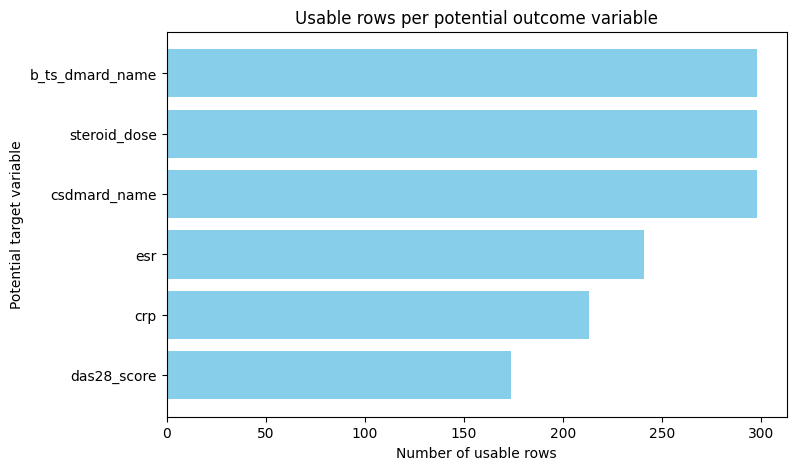

            target  usable_rows
0      das28_score          174
4              crp          213
5              esr          241
1     csdmard_name          298
3     steroid_dose          298
2  b_ts_dmard_name          298


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# List of candidate targets
targets = ['das28_score', 'csdmard_name', 'b_ts_dmard_name', 'steroid_dose', 'crp', 'esr']  # add other potential targets

rows_available = []

for target in targets:
    # Count rows where target is not missing
    usable_rows = df_cleaned[target].notna().sum()
    rows_available.append(usable_rows)

# Create a summary DataFrame
df_summary = pd.DataFrame({
    'target': targets,
    'usable_rows': rows_available
})

# Sort by usable rows
df_summary = df_summary.sort_values('usable_rows', ascending=True)

# Plot
plt.figure(figsize=(8,5))
plt.barh(df_summary['target'], df_summary['usable_rows'], color='skyblue')
plt.xlabel("Number of usable rows")
plt.ylabel("Potential target variable")
plt.title("Usable rows per potential outcome variable")
plt.show()

# Display table as well
print(df_summary)

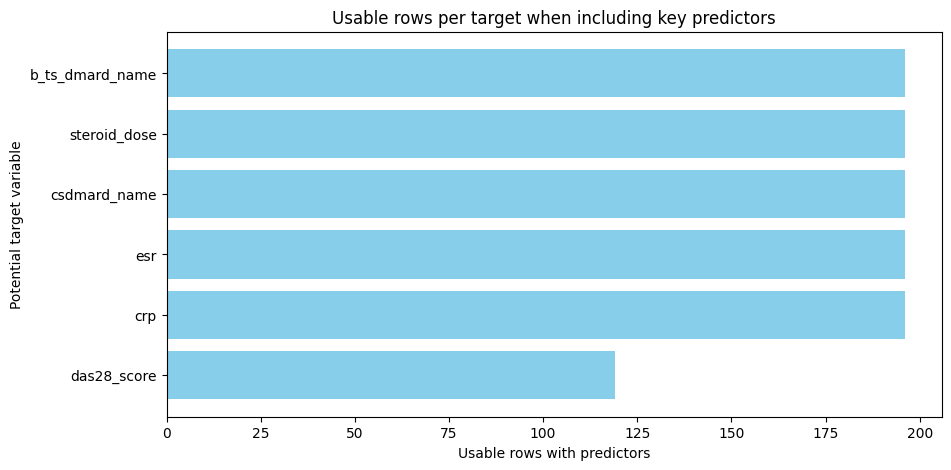

            target  usable_rows_with_predictors
0      das28_score                          119
1              crp                          196
2              esr                          196
3     csdmard_name                          196
4     steroid_dose                          196
5  b_ts_dmard_name                          196


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Candidate targets
targets = ['das28_score', 'crp', 'esr', 'csdmard_name', 'steroid_dose', 'b_ts_dmard_name']

# Key predictors you always want to include
predictors = ['crp', 'esr', 'csdmard_name', 'steroid_dose', 'b_ts_dmard_name']

rows_available = []

for target in targets:
    # Determine predictors to include for this target
    predictors_for_target = [p for p in predictors if p != target]
    
    # Count rows where target and all predictors are non-missing
    usable_rows = df_cleaned[[target] + predictors_for_target].dropna().shape[0]
    
    rows_available.append(usable_rows)

# Create summary DataFrame
df_summary = pd.DataFrame({
    'target': targets,
    'usable_rows_with_predictors': rows_available
})

# Sort for visualization
df_summary = df_summary.sort_values('usable_rows_with_predictors', ascending=True)

# Plot
plt.figure(figsize=(10,5))
plt.barh(df_summary['target'], df_summary['usable_rows_with_predictors'], color='skyblue')
plt.xlabel("Usable rows with predictors")
plt.ylabel("Potential target variable")
plt.title("Usable rows per target when including key predictors")
plt.show()

# Display table
print(df_summary)

In [63]:
print(f"Final dataset shape: {df_cleaned.shape}")
print(f"Number of unique patients: {df_cleaned['patient_id'].nunique()}")

Final dataset shape: (228, 34)
Number of unique patients: 70


In [28]:
# Does treatment intensity match disease activity?
df_cleaned['is_on_biologic'] = df_cleaned['b_ts_dmard_name'].apply(lambda x: 0 if x == 'None' else 1)
print(df_cleaned.groupby('is_on_biologic')['das28_score'].mean())

is_on_biologic
0    3.690864
1    3.539892
Name: das28_score, dtype: float64
